                      Timestamp  Temperature [degC]  Relative humidity [%]  \
0     2018-11-26 07:00:00+00:00           -4.518604              96.456200   
1     2018-11-26 07:10:00+00:00           -4.681363              96.873337   
2     2018-11-26 07:20:00+00:00           -4.879300              96.974167   
3     2018-11-26 07:30:00+00:00           -4.927025              97.301666   
4     2018-11-26 07:40:00+00:00           -4.965400              97.426666   
...                         ...                 ...                    ...   
1052  2018-12-03 14:20:00+00:00           -1.579112              96.272499   
1053  2018-12-03 14:30:00+00:00           -1.487630              96.220001   
1054  2018-12-03 14:40:00+00:00           -1.377834              96.135834   
1055  2018-12-03 14:50:00+00:00           -1.283477              95.991669   
1056  2018-12-03 15:00:00+00:00           -1.257813              95.866669   

      Pressure [hPa]  Solar radiation [W/m^2]  WdSpd - RefHt MM

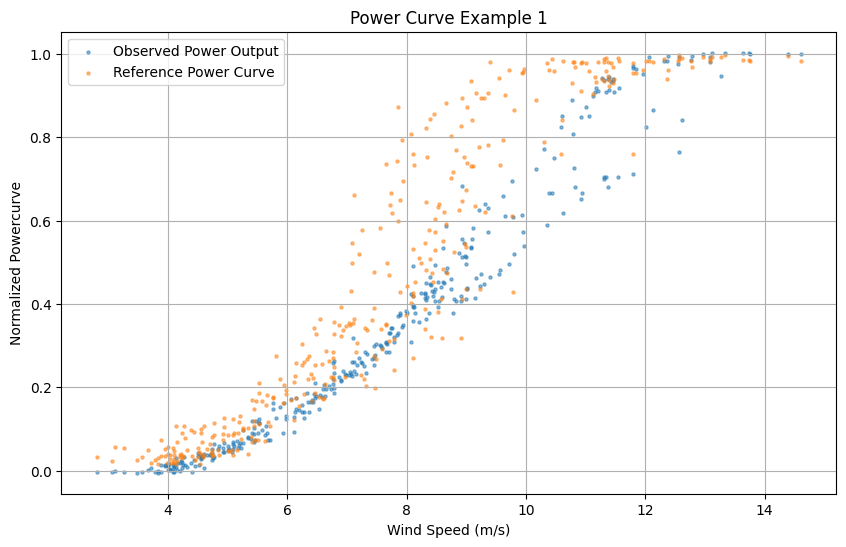

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from wind import get_powercurve, powercurve_gain, powercurve_gain_ref

folder = "data"

plt.figure(figsize=(10, 6))

            # Read CSV
df = pd.read_csv("data/Evt1_WEC001-Severe_icing_WEC002-Severe_icing.csv")
print(df)
df = df.dropna(subset=["WdSpd - RefHt WEC001 [m/s]","Power WEC001 Fraction of nomimal power [-]", 'Expected Power WEC002 [-]'])
print(df)
get_powercurve(
    df,
    x_axis="WdSpd - RefHt WEC001 [m/s]",
    y_axis="Power WEC001 Fraction of nomimal power [-]",
    expected_col= 'Expected Power WEC002 [-]',
    title=f"Power Curve Example 1"
)
# powercurve_gain_ref(
#     df,
#     min_points_per_bin = 2
# )
# plt.grid()
plt.savefig("example1.png")
plt.show()  


350
350


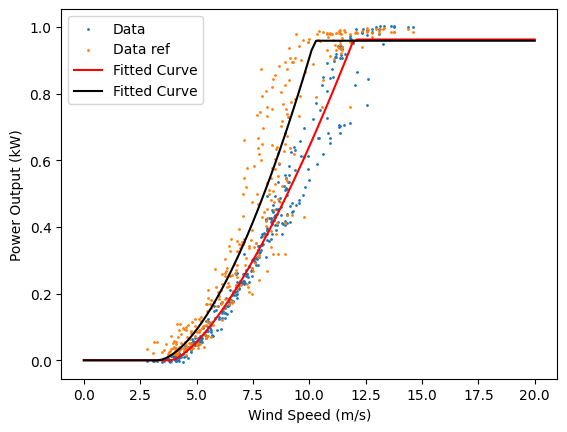

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Example cubic power curve function
def power_curve(v, P_rated, v_ci, v_r, k):
    """Cubic-based power curve for curve fitting."""
    v = np.array(v)
    P = np.zeros_like(v)
    # Between cut-in and rated speed
    mask = (v >= v_ci) & (v < v_r)
    P[mask] = P_rated * ((v[mask] - v_ci) / (v_r - v_ci))**k
    # Above rated speed
    P[v >= v_r] = P_rated
    return P


wind_speed = df["WdSpd - RefHt WEC001 [m/s]"].to_numpy()

power_output = df["Power WEC001 Fraction of nomimal power [-]"].to_numpy()
power_output_ref = df["Expected Power WEC002 [-]"].to_numpy()
v_fit = np.linspace(0, 20, 100)
print(len(wind_speed))
print(len(power_output))
# Fit the curve
popt, pcov = curve_fit(power_curve, wind_speed, power_output, p0=[800, 3, 10, 3])
P_rated_fit = power_curve(v_fit, *popt)
popt_ref, pcov = curve_fit(power_curve, wind_speed, power_output_ref, p0=[800, 3, 10, 3])
P_rated_fit_ref = power_curve(v_fit, *popt_ref)
# Plot
plt.scatter(wind_speed, power_output, label='Data', s = 1)
plt.scatter(wind_speed, power_output_ref, label='Data ref', s = 1)

plt.plot(v_fit, P_rated_fit, label='Fitted Curve', color='red')
plt.plot(v_fit, P_rated_fit_ref, label='Fitted Curve', color='black')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (kW)')
plt.legend()

plt.show()


Fitted Weibull parameters: shape (k)=3.14, scale (lambda)=8.50


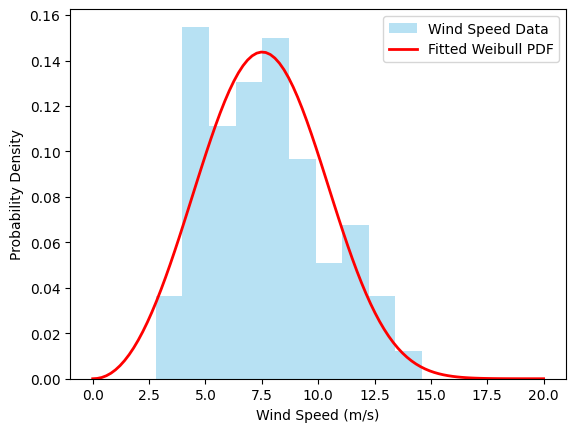

In [43]:
import numpy as np
from scipy.stats import weibull_min
import matplotlib.pyplot as plt

# Fit Weibull distribution
shape, loc, scale = weibull_min.fit(wind_speed, floc=0)  # fix loc=0

print(f"Fitted Weibull parameters: shape (k)={shape:.2f}, scale (lambda)={scale:.2f}")

# Plot histogram and fitted PDF
# v = np.linspace(0, max(wind_speed)+5, 100)
pdf_fitted = weibull_min.pdf(v_fit, shape, loc=0, scale=scale)

plt.hist(wind_speed, bins=10, density=True, alpha=0.6, color='skyblue', label='Wind Speed Data')
plt.plot(v_fit, pdf_fitted, 'r-', lw=2, label='Fitted Weibull PDF')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

Estimated Annual Energy Production (AEP): 3148 kWh/year Reference 4089 kWh/year
Loss = 0.770


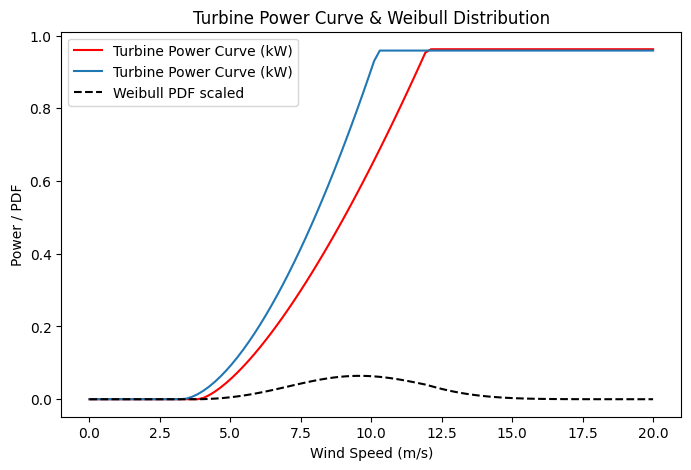

In [48]:
import numpy as np
from scipy.stats import weibull_min
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# -----------------------------
# Step 3: Calculate AEP
# -----------------------------
# v = np.linspace(0, 25, 1000)  # discretize wind speeds
# pdf = weibull_min.pdf(v, shape, loc=0, scale=scale)
# power = power_curve(v, P_rated_fit, v_ci_fit, v_r_fit, k_fit)

# Expected power (weighted by probability)
expected_power = P_rated_fit * pdf_fitted
expected_power_ref = P_rated_fit_ref * pdf_fitted
# Integrate using trapezoidal rule
aep = 8760 * np.trapezoid(expected_power, v_fit)  # kWh/year
aep_ref = 8760 * np.trapezoid(expected_power_ref, v_fit)  

print(f"Estimated Annual Energy Production (AEP): {aep:.0f} kWh/year Reference {aep_ref:.0f} kWh/year")
print(f"Loss = {aep / aep_ref:.3f}")

# -----------------------------
# Step 4: Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(v_fit, P_rated_fit, 'r-', label='Turbine Power Curve (kW)')
plt.plot(v_fit, P_rated_fit_ref, label='Turbine Power Curve (kW)')
plt.plot(v_fit, expected_power, 'k--', label='Weibull PDF scaled')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power / PDF')
plt.legend()
plt.title('Turbine Power Curve & Weibull Distribution')
plt.show()